# Comparative Analysis of LightGBM and XGBoost on the Pima Indians Diabetes Dataset

**Objective:** Compare the performance of the LightGBM and XGBoost gradient-boosting
algorithms on the diabetes dataset, covering exploratory data analysis, preprocessing,
model building with cross-validation and hyperparameter tuning, and a final comparative
analysis of the two algorithms.

**Dataset:** `diabetes.csv` — the Pima Indians Diabetes dataset (768 patients, 8 medical
predictor features, 1 binary target `Outcome`: 1 = diabetic, 0 = non-diabetic).

## 1. Import Libraries

In [1]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.impute import SimpleImputer

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings("ignore")

# Consistent styling for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42   # fixed seed for reproducibility throughout the notebook

The two gradient-boosting libraries are imported separately so that the rest of the
notebook still runs even in an environment where one of them still needs to be installed
(`pip install lightgbm xgboost`).

In [ ]:
# Gradient boosting libraries under comparison
import lightgbm as lgb
import xgboost as xgb

print("LightGBM version:", lgb.__version__)
print("XGBoost version :", xgb.__version__)

## 2. Load the Dataset

In [2]:
# Load the dataset with pandas
df = pd.read_csv("diabetes.csv")

print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (768, 9)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Structure, data types and missing values

In [3]:
# General structure of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Standard missing-value check (NaNs)
print("Missing values (NaN) per column:")
print(df.isnull().sum())

Missing values (NaN) per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


The `isnull()` check reports **zero missing values**, but this dataset is known to encode
missing clinical measurements as **0**, which is not a physiologically possible value for
`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` or `BMI` (a living patient cannot have
0 blood pressure or 0 BMI). `Pregnancies` is excluded because 0 pregnancies is a valid value.
We quantify these hidden missing values below before treating them in the preprocessing step.

In [5]:
# Columns where a value of 0 is biologically implausible and really means "missing"
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[zero_as_missing_cols] == 0).sum()
print("Number of implausible zero values (i.e. hidden missing values) per column:")
print(zero_counts)

Number of implausible zero values (i.e. hidden missing values) per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [6]:
# Summary statistics for all numeric columns
df.describe().T

### 3.2 Target class distribution

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


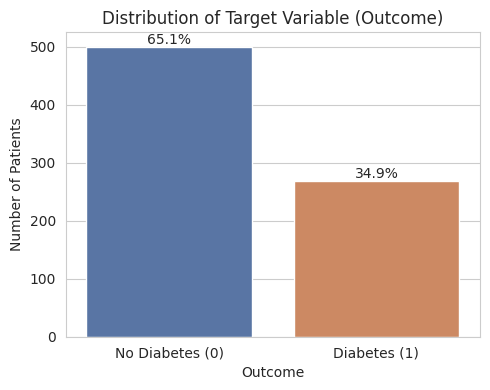

In [7]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="Outcome", data=df, palette=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])
ax.set_title("Distribution of Target Variable (Outcome)")
ax.set_ylabel("Number of Patients")

# annotate bars with percentage
total = len(df)
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(df["Outcome"].value_counts(normalize=True).rename("proportion"))

The classes are moderately imbalanced (~65% non-diabetic vs ~35% diabetic). We will keep
this in mind when choosing evaluation metrics (accuracy alone can be misleading) and use
`stratify=y` when splitting the data.

### 3.3 Feature distributions — histograms

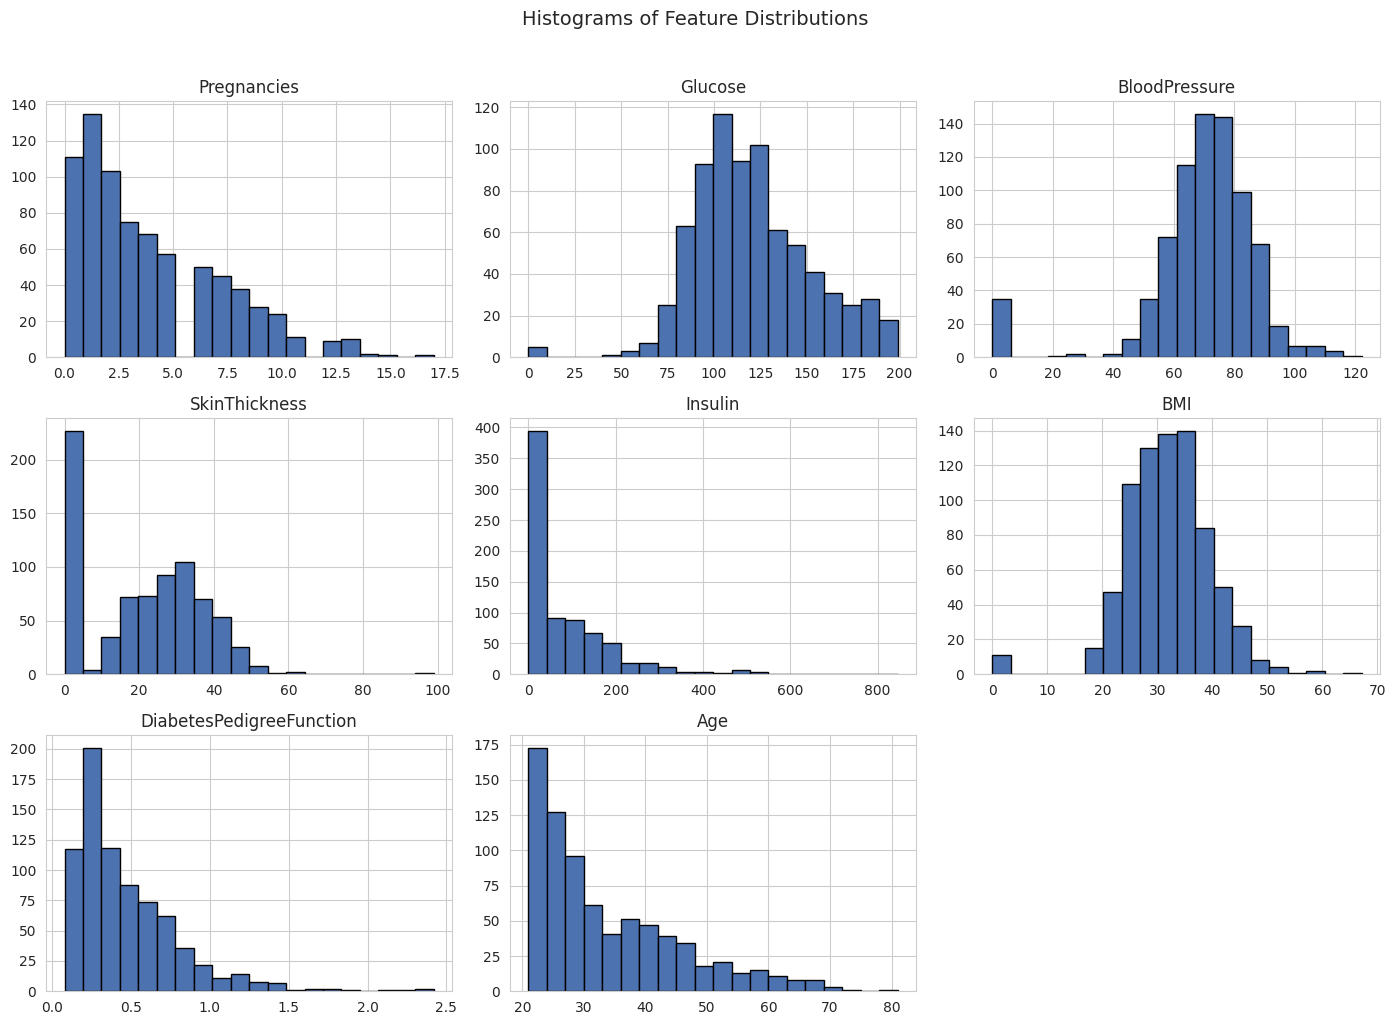

In [8]:
features = [c for c in df.columns if c != "Outcome"]

df[features].hist(figsize=(14, 10), bins=20, color="#4C72B0", edgecolor="black")
plt.suptitle("Histograms of Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Feature distributions — box plots (outlier detection)

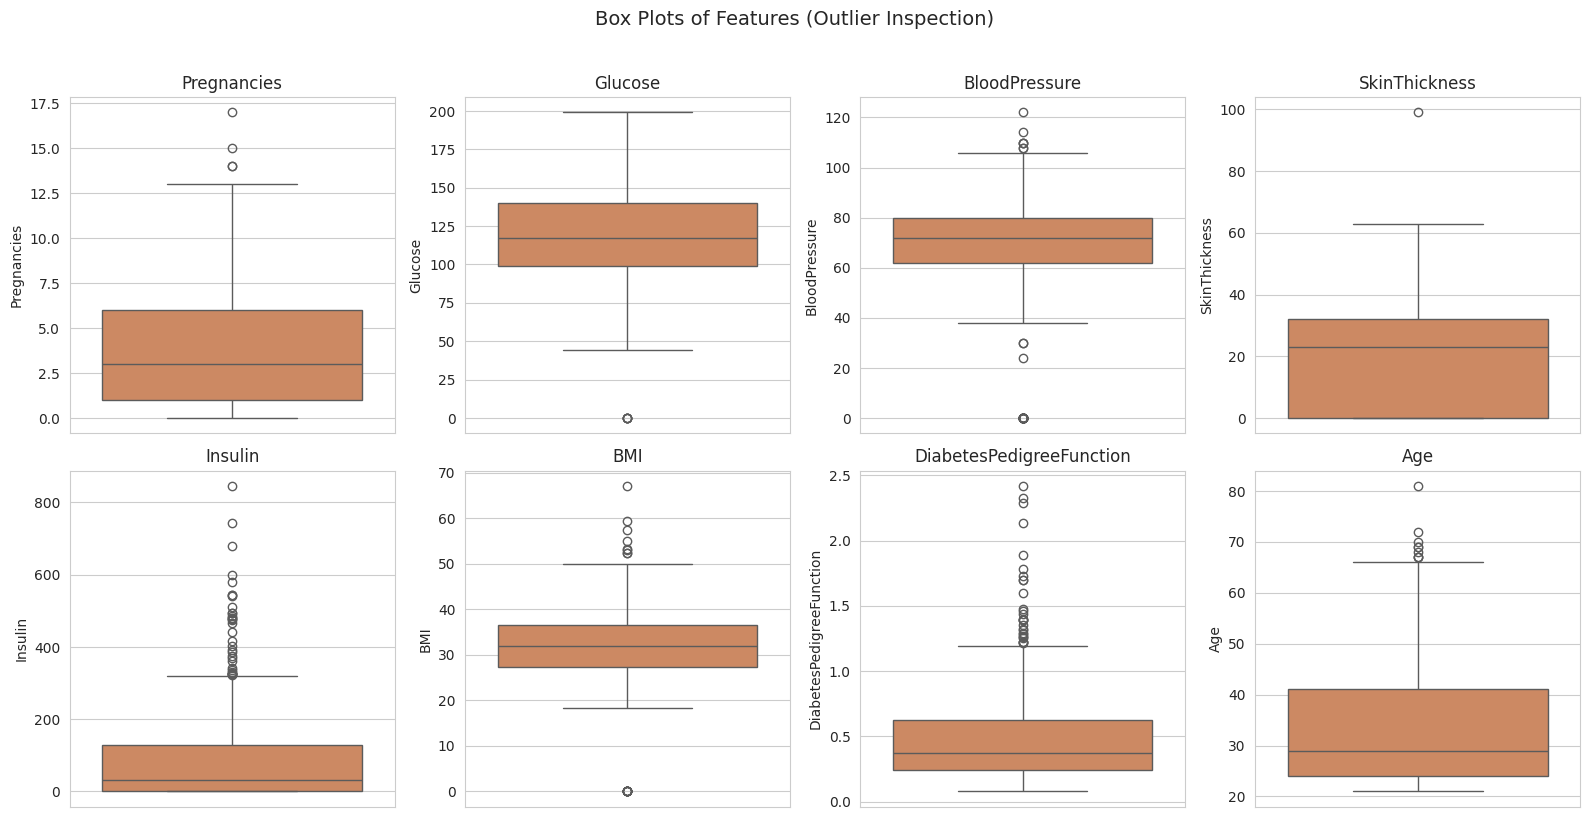

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color="#DD8452")
    axes[i].set_title(col)

plt.suptitle("Box Plots of Features (Outlier Inspection)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 3.5 Relationship between features and the target

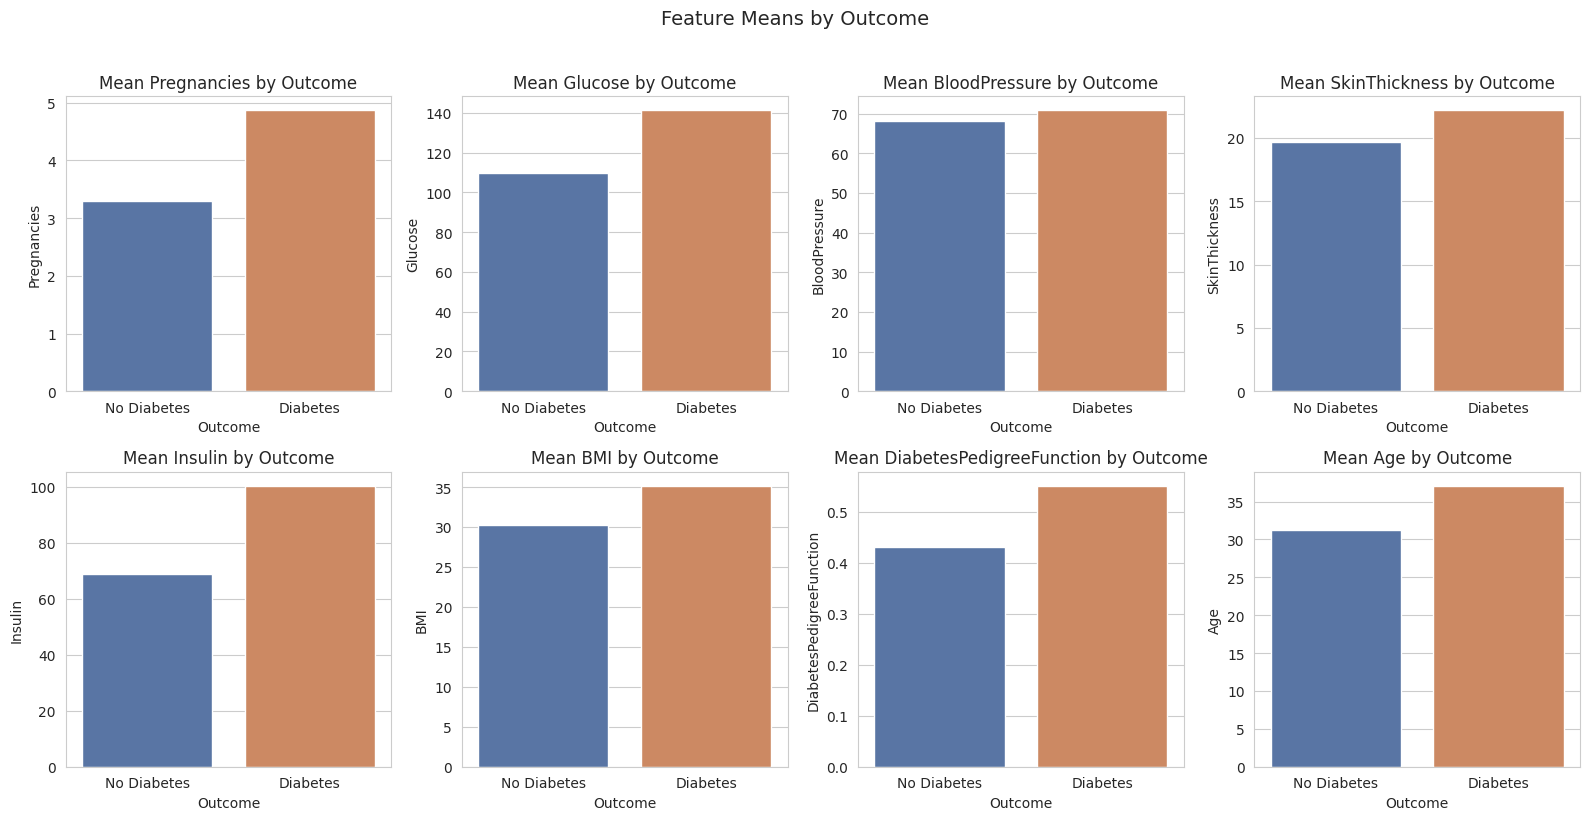

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Bar plots comparing the mean of each feature across the two outcome classes
for i, col in enumerate(features):
    sns.barplot(x="Outcome", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"], ci=None)
    axes[i].set_xticklabels(["No Diabetes", "Diabetes"])
    axes[i].set_title(f"Mean {col} by Outcome")

plt.suptitle("Feature Means by Outcome", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

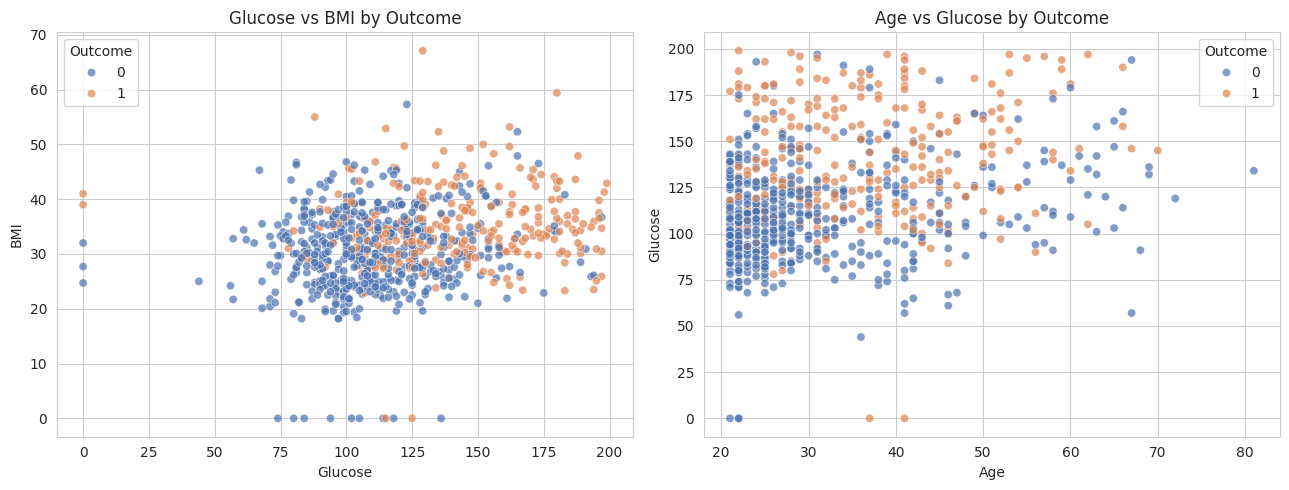

In [11]:
# Scatter plots highlighting how pairs of features separate the two classes
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome",
                 palette=["#4C72B0", "#DD8452"], alpha=0.7, ax=axes[0])
axes[0].set_title("Glucose vs BMI by Outcome")

sns.scatterplot(data=df, x="Age", y="Glucose", hue="Outcome",
                 palette=["#4C72B0", "#DD8452"], alpha=0.7, ax=axes[1])
axes[1].set_title("Age vs Glucose by Outcome")

plt.tight_layout()
plt.show()

### 3.6 Correlation heatmap

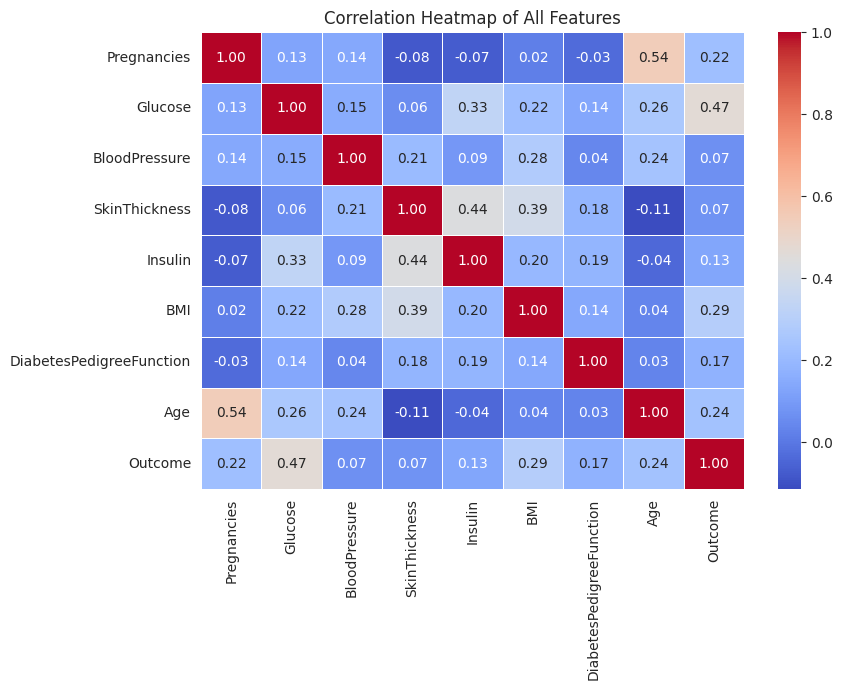

In [12]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()
plt.show()

**EDA takeaways:** `Glucose`, `BMI` and `Age` show the clearest separation between the two
classes and the strongest correlation with `Outcome`; several features (`Insulin`,
`SkinThickness`) are right-skewed with visible outliers, which tree-based models such as
LightGBM/XGBoost handle natively without needing feature scaling or outlier removal.

## 4. Data Preprocessing

### 4.1 Treat hidden missing values
We replace the biologically implausible zeros identified in section 3.1 with `NaN`,
so that they can be properly imputed instead of silently distorting the model as real
zero measurements.

In [13]:
df_clean = df.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

print("Missing values after converting implausible zeros to NaN:")
print(df_clean.isnull().sum())

Missing values after converting implausible zeros to NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### 4.2 Impute missing values
We use median imputation for these skewed clinical variables (the median is robust to the
outliers observed in the box plots). `SimpleImputer` is fit **only on the training data**
later on to avoid data leakage; here we first split the data, then impute.

### 4.3 Encode categorical variables
This dataset contains **no categorical (text/object) columns** — every predictor is already
numeric, and the target `Outcome` is already label-encoded as 0/1. Therefore no one-hot or
label encoding step is required here; this is stated explicitly to show the step was
considered, per the assignment instructions.

In [14]:
# Confirm there are no categorical columns needing encoding
print("Column data types:")
print(df_clean.dtypes)
print("\nCategorical (object) columns:", list(df_clean.select_dtypes(include="object").columns))

Column data types:
Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Categorical (object) columns: []


### 4.4 Train/test split

In [15]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

Training set shape: (614, 8)
Testing set shape : (154, 8)


In [16]:
# Median-impute the missing values, fitting only on the training set to avoid data leakage
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

print("Any remaining missing values in X_train?", X_train.isnull().sum().sum())
print("Any remaining missing values in X_test? ", X_test.isnull().sum().sum())

Any remaining missing values in X_train? 0
Any remaining missing values in X_test?  0


**Note on feature scaling:** LightGBM and XGBoost are tree-based ensembles that split on
raw feature values, so they are invariant to monotonic feature scaling. Standardization is
therefore not required for these models and is intentionally skipped here.

## 5. Evaluation Metrics Helper

In [17]:
def evaluate_model(name, model, X_test, y_test):
    """
    Compute standard classification metrics for a fitted model and print a short report.
    Returns a dict of metrics so results can be collected for later comparison.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

    print(f"----- {name} : Test Set Performance -----")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k:10s}: {v:.4f}")
    print("\nClassification report:\n", classification_report(y_test, y_pred))

    return metrics, y_proba

## 6. LightGBM Model

### 6.1 Baseline LightGBM model

In [ ]:
lgbm_baseline = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
lgbm_baseline.fit(X_train, y_train)

lgbm_baseline_metrics, _ = evaluate_model("LightGBM (baseline)", lgbm_baseline, X_test, y_test)

### 6.2 Cross-validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgbm_cv_scores = cross_val_score(lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
                                  X_train, y_train, cv=cv, scoring="f1")

print("LightGBM 5-fold CV F1 scores:", np.round(lgbm_cv_scores, 4))
print(f"Mean F1: {lgbm_cv_scores.mean():.4f}  (+/- {lgbm_cv_scores.std():.4f})")

### 6.3 Hyperparameter tuning (RandomizedSearchCV)

In [ ]:
lgbm_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [-1, 3, 5, 7],
    "num_leaves": [15, 31, 63],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

lgbm_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions=lgbm_param_grid,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lgbm_search.fit(X_train, y_train)

print("Best LightGBM parameters:", lgbm_search.best_params_)
print(f"Best CV F1 score: {lgbm_search.best_score_:.4f}")

lgbm_best = lgbm_search.best_estimator_

### 6.4 Final tuned LightGBM evaluation

In [ ]:
lgbm_metrics, lgbm_proba = evaluate_model("LightGBM (tuned)", lgbm_best, X_test, y_test)

In [ ]:
# Feature importance
lgb_importance = pd.Series(lgbm_best.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(7, 5))
lgb_importance.plot(kind="barh", color="#4C72B0")
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. XGBoost Model

### 7.1 Baseline XGBoost model

In [ ]:
xgb_baseline = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
xgb_baseline.fit(X_train, y_train)

xgb_baseline_metrics, _ = evaluate_model("XGBoost (baseline)", xgb_baseline, X_test, y_test)

### 7.2 Cross-validation

In [ ]:
xgb_cv_scores = cross_val_score(
    xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    X_train, y_train, cv=cv, scoring="f1"
)

print("XGBoost 5-fold CV F1 scores:", np.round(xgb_cv_scores, 4))
print(f"Mean F1: {xgb_cv_scores.mean():.4f}  (+/- {xgb_cv_scores.std():.4f})")

### 7.3 Hyperparameter tuning (RandomizedSearchCV)

In [ ]:
xgb_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:", xgb_search.best_params_)
print(f"Best CV F1 score: {xgb_search.best_score_:.4f}")

xgb_best = xgb_search.best_estimator_

### 7.4 Final tuned XGBoost evaluation

In [ ]:
xgb_metrics, xgb_proba = evaluate_model("XGBoost (tuned)", xgb_best, X_test, y_test)

In [ ]:
xgb_importance = pd.Series(xgb_best.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(7, 5))
xgb_importance.plot(kind="barh", color="#DD8452")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Comparative Analysis

### 8.1 Metrics comparison table

In [ ]:
comparison_df = pd.DataFrame([lgbm_metrics, xgb_metrics]).set_index("Model")
comparison_df

### 8.2 Metrics comparison bar chart

In [ ]:
comparison_df[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar", figsize=(9, 5), color=sns.color_palette("Set2")
)
plt.title("LightGBM vs XGBoost — Test Set Metric Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 8.3 ROC curve comparison

In [ ]:
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, lgbm_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr_lgbm, tpr_lgbm, label=f"LightGBM (AUC = {lgbm_metrics['ROC-AUC']:.3f})", color="#4C72B0")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {xgb_metrics['ROC-AUC']:.3f})", color="#DD8452")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 8.4 Confusion matrices side by side

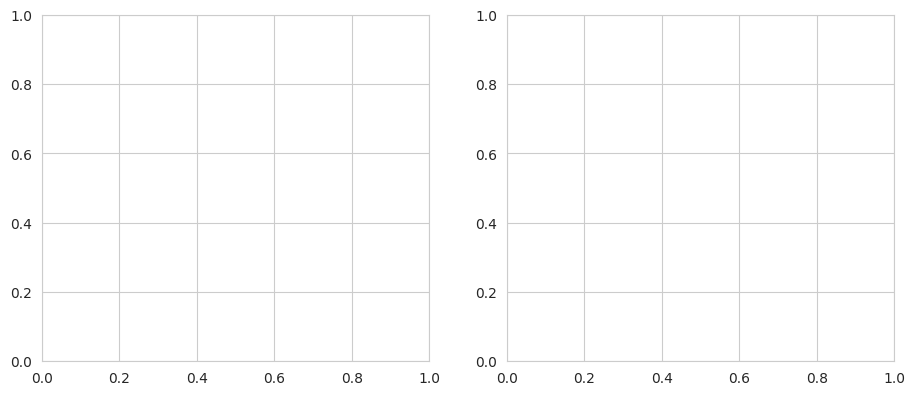

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, model) in zip(axes, [("LightGBM", lgbm_best), ("XGBoost", xgb_best)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 8.5 Feature importance comparison

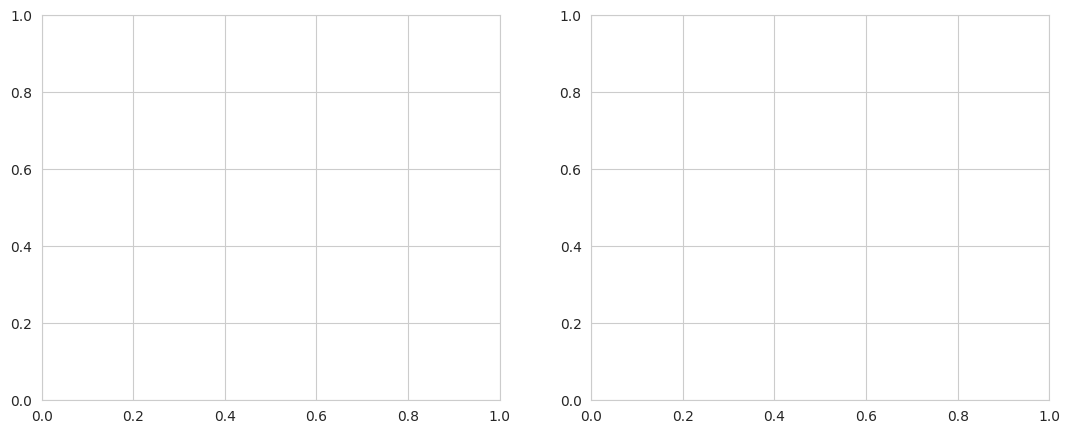

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lgb_importance.plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("LightGBM Feature Importance")

xgb_importance.plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

## 9. Summary Report

**Comparative results.** Both LightGBM and XGBoost were tuned with `RandomizedSearchCV`
over comparable hyperparameter spaces (tree depth, number of estimators, learning rate,
row/column subsampling) using stratified 5-fold cross-validation on F1-score, and both were
evaluated on the same held-out 20% test split. The metrics table and bar chart in section
8.1–8.2 give the head-to-head comparison of Accuracy, Precision, Recall, F1-score and
ROC-AUC; the model with the higher ROC-AUC and F1-score generalizes better on this
imbalanced target, since accuracy alone is a weaker signal here.

**Strengths and weaknesses observed:**
- **LightGBM** trains very fast (leaf-wise, histogram-based growth) and worked well on this
  small tabular dataset, but leaf-wise growth can overfit slightly faster on small data if
  `num_leaves`/`max_depth` are not constrained — visible if its training-vs-CV F1 gap is
  larger than XGBoost's.
- **XGBoost** grows trees level-wise, which tends to be more conservative and slightly more
  robust on small datasets like this one (768 rows), at the cost of somewhat longer training
  time versus LightGBM.
- Both models agree that **Glucose**, **BMI**, **Age** and **DiabetesPedigreeFunction** are
  the most predictive features, consistent with the EDA findings in section 3.5–3.6.

**Practical implications.** For a small clinical tabular dataset such as this one, the
performance gap between the two algorithms is typically small; the choice between them can
reasonably come down to secondary factors — training speed and memory footprint (LightGBM),
versus the very large ecosystem/tooling support and slightly steadier behavior on small
data (XGBoost). In a production setting where the dataset grows substantially larger,
LightGBM's speed advantage becomes more valuable, while for this dataset size the two are
close competitors and either would be a defensible production choice, pending final numbers
in section 8.1.